In [1]:
import os
import sys
from pathlib import Path
import numpy as np
import torch
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath('..'))
from src.ssl_contrastive import ContrastiveSSLModel, GridDataAugmenter, NTXentLoss

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Executing SSL Contrastive Pretraining on: {device}")

# 1. Ingest LCL pretraining windows (Phase 4 artifact)
lcl_path = Path('../data/ssl_pretraining/lcl_windows.npz')
npz_data = np.load(lcl_path)

X_train_lcl = npz_data['X_train']  # (12217, 48, 25)
X_val_lcl   = npz_data['X_val']    # (2581, 48, 25)

train_loader = DataLoader(
    TensorDataset(torch.from_numpy(X_train_lcl)),
    batch_size=128,
    shuffle=True,
    drop_last=True,
    pin_memory=True
)
val_loader = DataLoader(
    TensorDataset(torch.from_numpy(X_val_lcl)),
    batch_size=128,
    shuffle=False,
    drop_last=True
)

# 2. Instantiate Model, Augmenter & Criterion
augmenter = GridDataAugmenter()
model = ContrastiveSSLModel(
    in_channels=25,
    cnn_hidden_dims=(64, 128),
    lstm_hidden_dim=128,
    lstm_layers=2,
    proj_dim=64
).to(device)

criterion = NTXentLoss(temperature=0.1)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=15, eta_min=1e-5)

print("Contrastive model and dataloaders prepared successfully.")

Executing SSL Contrastive Pretraining on: cuda
Contrastive model and dataloaders prepared successfully.


In [2]:
EPOCHS = 15
history = {'train_loss': [], 'val_loss': []}
best_val_loss = float('inf')

print(f"--- Starting SSL Contrastive Pretraining ({EPOCHS} Epochs) ---")
for epoch in range(1, EPOCHS + 1):
    model.train()
    running_train_loss = 0.0
    
    for (x_batch,) in train_loader:
        x_batch = x_batch.to(device)
        
        # 1. Generate two stochastic augmented views
        view_A = augmenter.generate_augmented_view(x_batch)
        view_B = augmenter.generate_augmented_view(x_batch)
        
        optimizer.zero_grad()
        
        # 2. Forward pass through shared backbone + projection head
        _, z_A = model(view_A)
        _, z_B = model(view_B)
        
        # 3. Contrastive InfoNCE computation
        loss = criterion(z_A, z_B)
        loss.backward()
        
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()
        running_train_loss += loss.item()
        
    train_loss = running_train_loss / len(train_loader)
    scheduler.step()
    
    # Validation Loop
    model.eval()
    running_val_loss = 0.0
    with torch.no_grad():
        for (x_batch,) in val_loader:
            x_batch = x_batch.to(device)
            view_A = augmenter.generate_augmented_view(x_batch)
            view_B = augmenter.generate_augmented_view(x_batch)
            
            _, z_A = model(view_A)
            _, z_B = model(view_B)
            
            loss = criterion(z_A, z_B)
            running_val_loss += loss.item()
            
    val_loss = running_val_loss / len(val_loader)
    
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    
    # Save the best encoder backbone checkpoint
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        save_dir = Path('../saved_models')
        save_dir.mkdir(parents=True, exist_ok=True)
        torch.save(model.state_dict(), save_dir / 'ssl_contrastive_full.pth')
        torch.save(model.encoder.state_dict(), save_dir / 'ssl_contrastive_pretrained_encoder.pth')

    if epoch % 3 == 0 or epoch == 1:
        print(f"Epoch [{epoch:02d}/{EPOCHS:02d}] | Train NT-Xent: {train_loss:.4f} | Val NT-Xent: {val_loss:.4f}")

print(f"\nContrastive Pretraining Completed. Best Val Loss: {best_val_loss:.4f}")
print("Encoder weights saved to: ../saved_models/ssl_contrastive_pretrained_encoder.pth")

--- Starting SSL Contrastive Pretraining (15 Epochs) ---
Epoch [01/15] | Train NT-Xent: 0.4460 | Val NT-Xent: 3.5315
Epoch [03/15] | Train NT-Xent: 0.1408 | Val NT-Xent: 2.3914
Epoch [06/15] | Train NT-Xent: 0.0985 | Val NT-Xent: 2.0335
Epoch [09/15] | Train NT-Xent: 0.0831 | Val NT-Xent: 1.8826
Epoch [12/15] | Train NT-Xent: 0.0773 | Val NT-Xent: 1.7399
Epoch [15/15] | Train NT-Xent: 0.0762 | Val NT-Xent: 1.7086

Contrastive Pretraining Completed. Best Val Loss: 1.7086
Encoder weights saved to: ../saved_models/ssl_contrastive_pretrained_encoder.pth


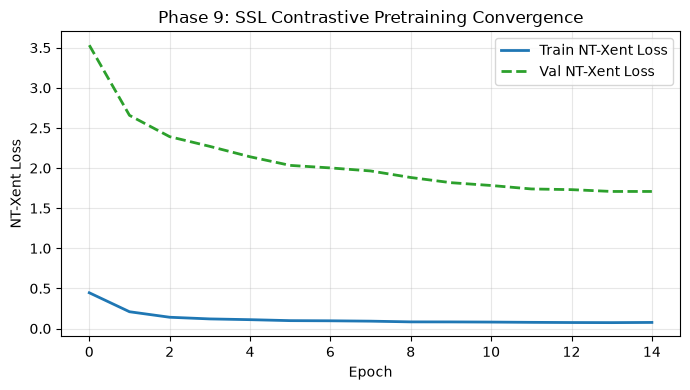

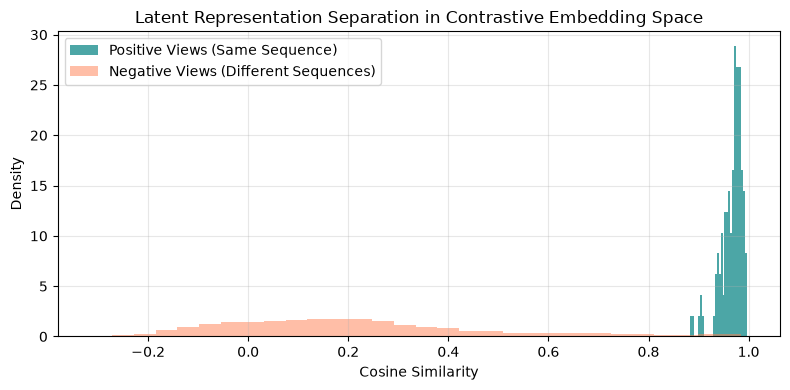

In [3]:
# 1. Plot Training vs Validation NT-Xent Loss
fig_dir = Path('../results/figures')
fig_dir.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(7, 4))
plt.plot(history['train_loss'], label='Train NT-Xent Loss', color='#1f77b4', lw=2)
plt.plot(history['val_loss'], label='Val NT-Xent Loss', color='#2ca02c', lw=2, linestyle='--')
plt.xlabel('Epoch')
plt.ylabel('NT-Xent Loss')
plt.title('Phase 9: SSL Contrastive Pretraining Convergence')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(fig_dir / 'ssl_contrastive_convergence.png', dpi=300)
plt.show()

# 2. Inspect Positive Pair vs Negative Pair Cosine Similarities
model.eval()
with torch.no_grad():
    sample_batch = next(iter(val_loader))[0].to(device)
    vA = augmenter.generate_augmented_view(sample_batch)
    vB = augmenter.generate_augmented_view(sample_batch)
    
    _, zA = model(vA)
    _, zB = model(vB)
    
    zA_norm = torch.nn.functional.normalize(zA, dim=1)
    zB_norm = torch.nn.functional.normalize(zB, dim=1)
    
    # Cosine similarities of positive pairs (diagonal)
    pos_sims = (zA_norm * zB_norm).sum(dim=1).cpu().numpy()
    
    # Cosine similarities of negative pairs (off-diagonal)
    sim_matrix = torch.matmul(zA_norm, zB_norm.T).cpu().numpy()
    np.fill_diagonal(sim_matrix, np.nan)
    neg_sims = sim_matrix[~np.isnan(sim_matrix)]

plt.figure(figsize=(8, 4))
plt.hist(pos_sims, bins=30, alpha=0.7, color='teal', label='Positive Views (Same Sequence)', density=True)
plt.hist(neg_sims, bins=30, alpha=0.5, color='coral', label='Negative Views (Different Sequences)', density=True)
plt.title('Latent Representation Separation in Contrastive Embedding Space')
plt.xlabel('Cosine Similarity')
plt.ylabel('Density')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(fig_dir / 'ssl_contrastive_similarity_distribution.png', dpi=300)
plt.show()